In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [24]:
df = df[df['room_type'] == 'Shared room']

In [25]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace('.00', '', regex=False)
df['price'] = df['price'].str.replace(',000', '', regex=False)
df['price'] = df['price'].str.replace(',', '.', regex=False)
df['price'] = df['price'].astype(float)

In [26]:
df['property_type'] = df['property_type'].replace({
    'Shared room in parking space': '21',
    'Shared room in guest suite': '20',
    'Shared room in hostel': '19',
    'Shared room in rental unit': '18',
    'Shared room in home': '17',
    'Shared room in bed and breakfast': '16',
    'Shared room in boutique hotel': '15',
    'Shared room in villa': '14',
    'Shared room': '13',
    'Shared room in guesthouse': '12',
    'Shared room in hotel': '11',
    'Shared room in condo': '10',
    'Shared room in serviced apartment': '9',
    'Shared room in casa particular': '8',
    'Shared room in townhouse': '7',
    'Shared room in dome': '6',
    'Shared room in vacation home': '5',
    'Shared room in tiny home': '4',
    'Shared room in cabin': '3',
    'Shared room in bungalow': '2',
    'Shared room in kezhan': '1'
}, regex=False)

<ipython-input-27-a79b0d0a01aa>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


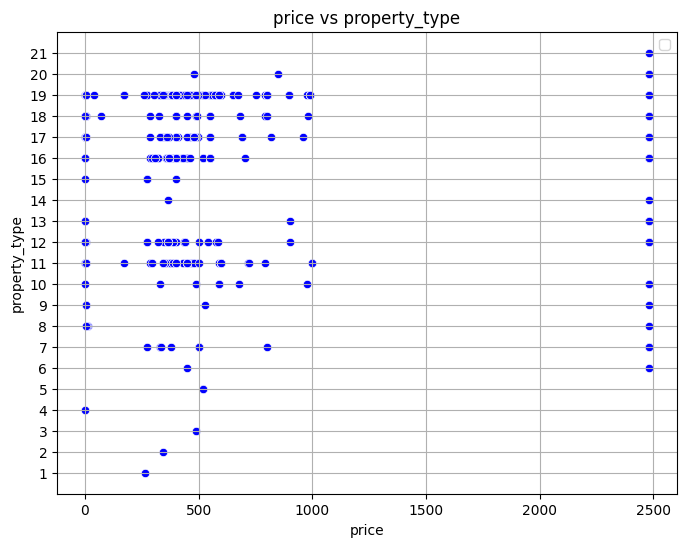

In [27]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='property_type', x='price',  color = 'blue', data=df)
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
indep= df[['property_type']]
dep = df[['price']]

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [30]:
model.fit(indep, dep)

LinearRegression()

In [31]:
type(model)

sklearn.linear_model._base.LinearRegression

In [32]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['property_type'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-20.07523101]]),
 'rank_': 1,
 'singular_': array([97.66750318]),
 'intercept_': array([1140.18881855])}

In [33]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-20.07523101]]
Intercepto: [1140.18881855]
y = [-20.07523101]x + [1140.18881855]


In [34]:
r2 = model.score(indep, dep)
r2

0.009294638338096184

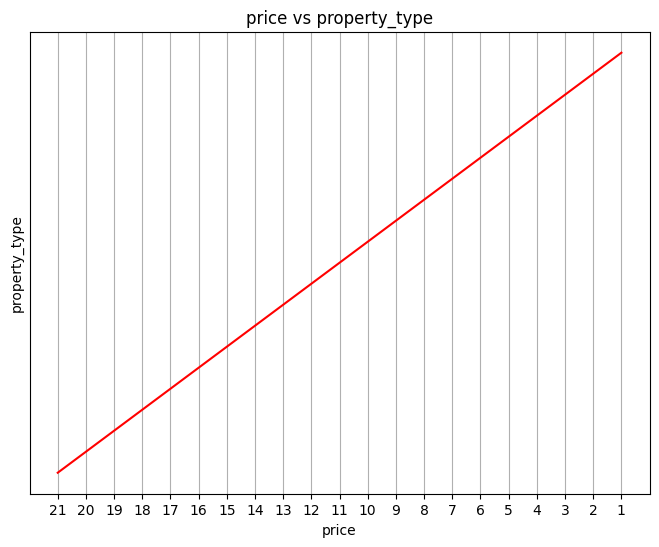

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(dep['price'], indep['property_type'], color='blue')
plt.plot(indep['property_type'], model.predict(indep), color='red')
plt.title('price vs property_type')
plt.xlabel('price')
plt.ylabel('property_type')
plt.grid(True)
plt.show()

In [36]:
yPred = model.predict(df[['property_type']])
yPred

array([[ 718.60896744],
       [ 738.68419845],
       [ 758.75942945],
       [ 738.68419845],
       [ 778.83466046],
       [ 758.75942945],
       [ 758.75942945],
       [ 798.90989146],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 818.98512247],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 798.90989146],
       [ 839.06035347],
       [ 758.75942945],
       [ 758.75942945],
       [ 839.06035347],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.75942945],
       [ 758.759

In [37]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
117,117,previous scrape,Near Bangkok more space than urban!,"IHouse Ekkamai Condo 56 sqm. 1 bedroom, 1 livi...","night-out street ""Ekkamai""",Sugarcane,02/02/2013,"Bangkok, Thailand",Investor relations manager in a high-end real ...,within an hour,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,718.608967
174,174,previous scrape,BANGKOK HUB DORM public transport,"Nested in the heart of bustling Bangkok, Bangk...","Many street food around, you wont worry about ...",Kriengkrai,06/09/2013,"Bangkok, Thailand",My inspiration is to have a place where friend...,within a few hours,...,4.44,4.80,4.80,4.69,4.69,4.73,4.56,0.21,4.80,738.684198
217,217,city scrape,S1 hostel (Dorm) Sathorn Bangkok,"Stylish budget hostel in the midst of Bangkok,...",Our hostel is located on small greenery road. ...,S1,19/11/2013,"Bangkok, Thailand",We are very welcome all our guests as our own ...,within an hour,...,4.53,4.61,4.73,4.73,4.62,4.37,4.59,0.76,4.61,758.759429
229,229,previous scrape,BANGKOK HUB : Standard Double Room,A room with minimalism & rustic design in Cult...,"Taking AIRPORT LINK to PHAYATHAI, then Sky Tra...",Kriengkrai,06/09/2013,"Bangkok, Thailand",My inspiration is to have a place where friend...,within an hour,...,5.00,5.00,5.00,5.00,5.00,4.50,4.50,0.02,5.00,738.684198
277,277,previous scrape,k79room near BTS Onnut,k79room HOSTEL is the best budget hostel becau...,"7-11, Tesco Lotus, Big C, Massage, BTS On Nut,...",Warut,21/02/2014,"Bangkok, Thailand","Our Aries building is a low rise, boutique bui...",within an hour,...,4.80,4.67,4.50,4.90,4.67,4.67,4.80,0.03,4.67,778.834660


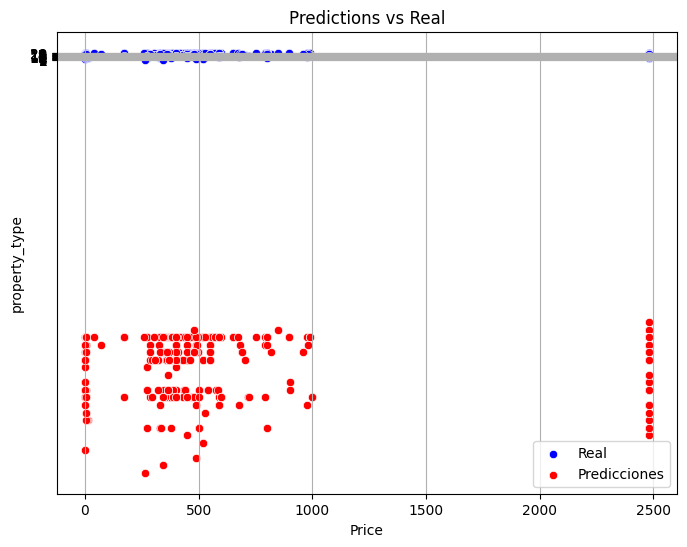

In [38]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='property_type', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('property_type')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
coefDe = model.score(indep, dep)
coefDe

0.009294638338096184

In [40]:
coefCo = np.sqrt(coefDe)
coefCo

0.09640870468010751

In [41]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared','', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Private half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' hared', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' S half-', '', regex=False)
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')
#df['bathrooms_text'] = df['bathrooms_text'].astype(float)
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '', regex=False)
df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)
df['host_response_rate'] = df['host_response_rate'].astype(float)
df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-41-a46314adb5de>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)
<ipython-input-41-a46314adb5de>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)
<ipython-input-41-a46314adb5de>:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

In [42]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','bedrooms','review_scores_value','reviews_per_month','property_type']]

In [43]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.044979,0.011061,-0.078036,NaN,0.055423,-0.042931,0.264265,-0.213465,0.127369,0.021980,-0.034321,-0.141224
host_is_superhost,0.044979,1.000000,-0.167507,0.017233,NaN,0.190277,0.164603,-0.001665,0.036391,-0.159052,0.186344,-0.108189,0.049709
price,0.011061,-0.167507,1.000000,-0.045589,NaN,-0.024084,-0.958144,-0.436047,-0.180323,0.686175,-0.072457,0.049713,-0.096409
accommodates,-0.078036,0.017233,-0.045589,1.000000,NaN,0.085658,-0.006584,-0.095226,-0.039990,-0.044214,0.076138,-0.083498,0.148994
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.055423,0.190277,-0.024084,0.085658,NaN,1.000000,0.063227,0.036700,-0.042990,-0.113933,0.584966,-0.489058,0.112778
host_identity_verified,-0.042931,0.164603,-0.958144,-0.006584,NaN,0.063227,1.000000,0.453233,0.181117,-0.709589,0.108902,-0.096160,0.112854
instant_bookable,0.264265,-0.001665,-0.436047,-0.095226,NaN,0.036700,0.453233,1.000000,0.092454,-0.392704,0.027673,-0.088671,-0.088622
host_total_listings_count,-0.213465,0.036391,-0.180323,-0.039990,NaN,-0.042990,0.181117,0.092454,1.000000,-0.173269,0.014081,0.022214,-0.058551
bedrooms,0.127369,-0.159052,0.686175,-0.044214,NaN,-0.113933,-0.709589,-0.392704,-0.173269,1.000000,-0.170211,0.229141,-0.188043


In [44]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month,property_type
host_acceptance_rate,1.000000,0.044979,0.011061,0.078036,NaN,0.055423,0.042931,0.264265,0.213465,0.127369,0.021980,0.034321,0.141224
host_is_superhost,0.044979,1.000000,0.167507,0.017233,NaN,0.190277,0.164603,0.001665,0.036391,0.159052,0.186344,0.108189,0.049709
price,0.011061,0.167507,1.000000,0.045589,NaN,0.024084,0.958144,0.436047,0.180323,0.686175,0.072457,0.049713,0.096409
accommodates,0.078036,0.017233,0.045589,1.000000,NaN,0.085658,0.006584,0.095226,0.039990,0.044214,0.076138,0.083498,0.148994
bathrooms_text,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_cleanliness,0.055423,0.190277,0.024084,0.085658,NaN,1.000000,0.063227,0.036700,0.042990,0.113933,0.584966,0.489058,0.112778
host_identity_verified,0.042931,0.164603,0.958144,0.006584,NaN,0.063227,1.000000,0.453233,0.181117,0.709589,0.108902,0.096160,0.112854
instant_bookable,0.264265,0.001665,0.436047,0.095226,NaN,0.036700,0.453233,1.000000,0.092454,0.392704,0.027673,0.088671,0.088622
host_total_listings_count,0.213465,0.036391,0.180323,0.039990,NaN,0.042990,0.181117,0.092454,1.000000,0.173269,0.014081,0.022214,0.058551
bedrooms,0.127369,0.159052,0.686175,0.044214,NaN,0.113933,0.709589,0.392704,0.173269,1.000000,0.170211,0.229141,0.188043


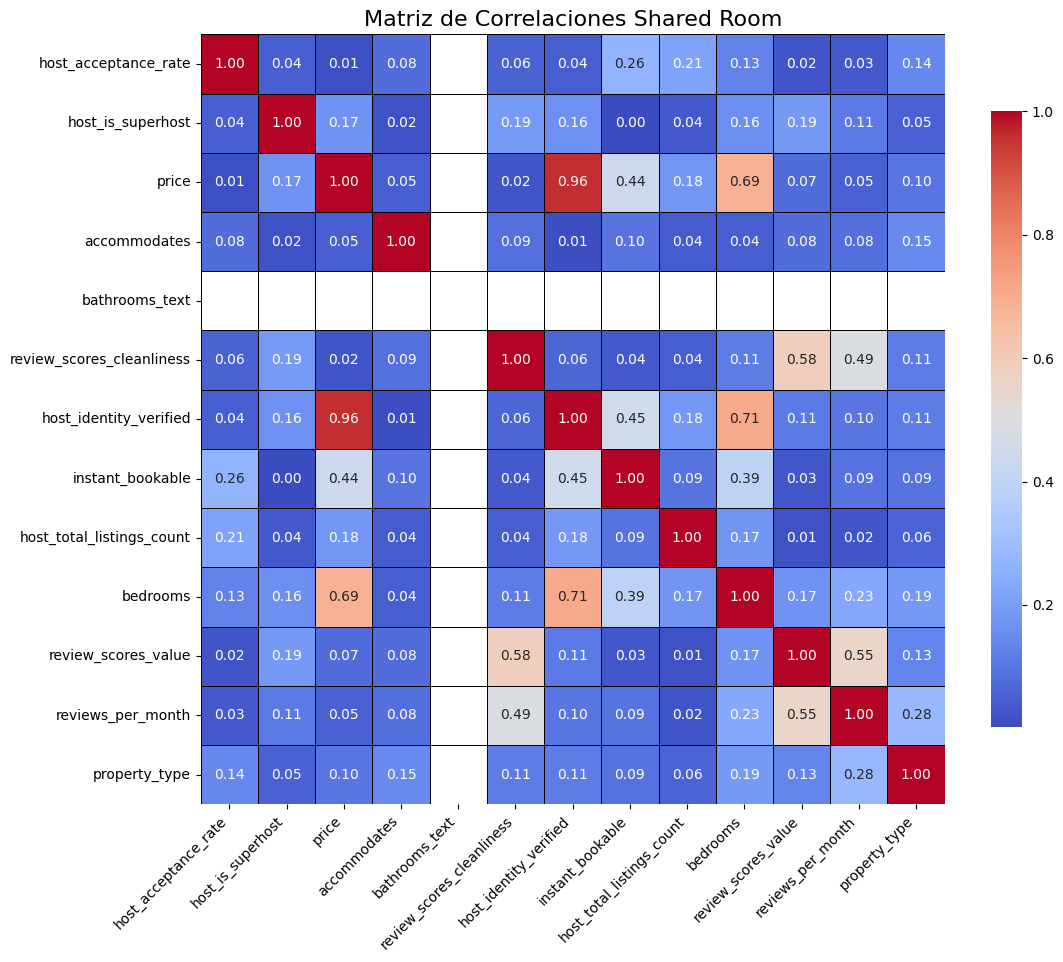

In [45]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Shared Room', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()